# RW-DA-004 — Chimeric Read Detection

Find all reads where a single read end produces **two consecutive genomic alignments**
(primary + supplementary), indicating a structural rearrangement at the split point.

**Chimeric-pair criteria (applied per read end):**
- Both alignments mapped, each spanning ≥ `MIN_ALN_LEN` bases on the read
- Read-coordinate overlap ≤ `MAX_OVERLAP` bp (default 20)
- Read-coordinate overlap ≤ `MAX_OVERLAP_FRAC` × length of the shorter alignment (default 50 %)

**Event types:**

| Type | Criterion |
|------|-----------|
| `translocation` | different chromosomes |
| `inversion` | same chrom, opposite strands |
| `large_deletion` | same chrom, same strand, ref gap ≥ `MIN_SV_SIZE` (1 kb) |
| `small_deletion` | same chrom, same strand, ref gap < 1 kb |
| `tandem_dup` | same chrom, same strand, second alignment maps upstream of first |

In [ ]:
import pysam
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path

CRAM_FILE = "/home/ec2-user/rw-da-003_data/GM25256-B6.name-sorted.cram"
REFERENCE = "/home/ec2-user/rw-da-003_data/Homo_sapiens_assembly38.fasta"
S3_BASE   = "s3://compbio-discovery-shared/nonLTR/wgs/rw-da-004/"

# ── Filters ────────────────────────────────────────────────────────────────
MIN_ALN_LEN            = 20    # min read-spanning length of each alignment (bp)
MAX_OVERLAP            = 20    # max allowed read-coordinate overlap (bp)
MAX_OVERLAP_FRAC       = 0.50  # overlap must not exceed this fraction of the shorter alignment
MIN_SV_SIZE            = 1_000 # ref-gap threshold: large_deletion vs small_deletion
MIN_COMPETING_ALN_FRAC = 0.80  # flag read if any other alignment covers ≥ this fraction of the read
MIN_JUNCTION_READS     = 4     # min supporting reads for a junction to be reported

# Set to an integer to limit reads for exploration; None = full CRAM
MAX_READS = 5_000_000

CANONICAL = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]

pysam.set_verbosity(0)   # silence missing-index warning (name-sorted CRAM has no .crai)

In [169]:
def to_fwd_coords(aln):
    """
    Return (start, end) of the aligned region in forward-read coordinates.
    Accounts for hard-clips used by BWA-MEM in supplementary alignments.
    """
    if not aln.cigartuples:
        return 0, 0
    leading_hard  = aln.cigartuples[0][1]  if aln.cigartuples[0][0]  == 5 else 0
    trailing_hard = aln.cigartuples[-1][1] if aln.cigartuples[-1][0] == 5 else 0
    rl = aln.query_length  # stored bases (hard-clipped excluded)
    if aln.is_reverse:
        fwd_start = trailing_hard + (rl - aln.query_alignment_end)
        fwd_end   = trailing_hard + (rl - aln.query_alignment_start)
    else:
        fwd_start = leading_hard + aln.query_alignment_start
        fwd_end   = leading_hard + aln.query_alignment_end
    return fwd_start, fwd_end


def is_valid_chimeric_pair(aln1, aln2):
    """
    Return True if the two alignments are consecutive on the read:
    read-coordinate overlap is within the allowed bounds.
    """
    s1, e1 = to_fwd_coords(aln1)
    s2, e2 = to_fwd_coords(aln2)
    len1, len2 = e1 - s1, e2 - s2
    if len1 < MIN_ALN_LEN or len2 < MIN_ALN_LEN:
        return False
    overlap = min(e1, e2) - max(s1, s2)  # negative = gap on read (fine)
    if overlap > MAX_OVERLAP:
        return False
    if overlap > 0 and overlap > MAX_OVERLAP_FRAC * min(len1, len2):
        return False
    return True


def classify_event(primary, suppl):
    """Classify the structural variant suggested by the chimeric pair."""
    c1, c2 = primary.reference_name, suppl.reference_name
    if c1 != c2:
        return "translocation"

    s1 = "-" if primary.is_reverse else "+"
    s2 = "-" if suppl.is_reverse   else "+"
    if s1 != s2:
        return "inversion"

    # Same chrom, same strand — determine order on read
    ps, pe = to_fwd_coords(primary)
    ss, se = to_fwd_coords(suppl)
    first, second = (primary, suppl) if ps < ss else (suppl, primary)

    if s1 == "+":
        ordered = first.reference_start < second.reference_start
        ref_gap = second.reference_start - first.reference_end
    else:  # both on minus strand: first on read maps to higher genomic pos
        ordered = first.reference_start > second.reference_start
        ref_gap = first.reference_start - second.reference_end

    if ordered:
        return "large_deletion" if ref_gap >= MIN_SV_SIZE else "small_deletion"
    return "tandem_dup"


def process_group(group, events):
    """Extract all valid chimeric pairs from one read-name group."""
    for is_r1 in (True, False):
        end_reads = [r for r in group if r.is_read1 == is_r1 and not r.is_secondary]
        primary   = next((r for r in end_reads
                          if not r.is_supplementary and not r.is_unmapped), None)
        if primary is None:
            continue
        suppls = [r for r in end_reads if r.is_supplementary and not r.is_unmapped]

        # All non-primary alignments for this read end (suppl + secondary),
        # used to detect competing full-read placements.
        all_alts = [r for r in group
                    if r.is_read1 == is_r1
                    and (r.is_supplementary or r.is_secondary)
                    and not r.is_unmapped]

        total_len = primary.query_length  # primary stores full read (no hard clips)

        for suppl in suppls:
            if not is_valid_chimeric_pair(primary, suppl):
                continue
            ps, pe = to_fwd_coords(primary)
            ss, se = to_fwd_coords(suppl)
            overlap = min(pe, se) - max(ps, ss)

            # Flag if any OTHER alignment covers ≥ MIN_COMPETING_ALN_FRAC of the
            # read in a single span — indicates a competing non-chimeric placement
            # (e.g. the read mapping fully to a repeat / decoy contig).
            full_aln_alt = any(
                (to_fwd_coords(alt)[1] - to_fwd_coords(alt)[0])
                >= MIN_COMPETING_ALN_FRAC * total_len
                for alt in all_alts if alt is not suppl
            )

            events.append({
                "read_name"        : primary.query_name,
                "read_end"         : "R1" if is_r1 else "R2",
                "chrom1"           : primary.reference_name,
                "pos1"             : primary.reference_start,
                "end1"             : primary.reference_end,
                "strand1"          : "-" if primary.is_reverse else "+",
                "mapq1"            : primary.mapping_quality,
                "read_s1"          : ps,
                "read_e1"          : pe,
                "chrom2"           : suppl.reference_name,
                "pos2"             : suppl.reference_start,
                "end2"             : suppl.reference_end,
                "strand2"          : "-" if suppl.is_reverse else "+",
                "mapq2"            : suppl.mapping_quality,
                "read_s2"          : ss,
                "read_e2"          : se,
                "overlap_bp"       : overlap,
                "event_type"       : classify_event(primary, suppl),
                "has_full_aln_alt" : full_aln_alt,
            })

In [170]:
t0     = time.time()
events = []

cram = pysam.AlignmentFile(
    CRAM_FILE, "rc",
    reference_filename=REFERENCE,
    threads=4,
)

current_name = None
group        = []
n_reads      = 0
n_groups     = 0

for read in cram:
    if read.query_name != current_name:
        if group:
            n_groups += 1
            process_group(group, events)
            if n_groups % 500_000 == 0:
                elapsed = time.time() - t0
                print(f"  {n_groups/1e6:.1f}M groups | {len(events):,} chimeric "
                      f"| {elapsed:.0f}s elapsed")
        current_name = read.query_name
        group = [read]
    else:
        group.append(read)
    n_reads += 1
    if MAX_READS and n_reads >= MAX_READS:
        break

# flush last group
if group:
    n_groups += 1
    process_group(group, events)

cram.close()

chimeric_df = pd.DataFrame(events)
elapsed = time.time() - t0
label = f"first {MAX_READS//1_000_000}M reads" if MAX_READS else "full CRAM"
print(f"\nScanned {n_reads:,} reads ({n_groups:,} groups) in {elapsed:.0f}s  [{label}]")
print(f"Chimeric pairs found: {len(chimeric_df):,}")
chimeric_df.head()

  0.5M groups | 5,052 chimeric | 4s elapsed
  1.0M groups | 10,208 chimeric | 7s elapsed
  1.5M groups | 15,439 chimeric | 10s elapsed
  2.0M groups | 20,708 chimeric | 13s elapsed

Scanned 5,000,000 reads (2,464,408 groups) in 16s  [first 5M reads]
Chimeric pairs found: 25,738


,read_name,read_end,chrom1,pos1,end1,strand1,mapq1,read_s1,read_e1,chrom2,pos2,end2,strand2,mapq2,read_s2,read_e2,overlap_bp,event_type,has_full_aln_alt
0,HMJG5DSX2211027:2:1101:1108:14904,R1,chr2,125532559,125532669,+,60,0,110,chr22,34601417,34601478,+,45,90,151,20,translocation,False
1,HMJG5DSX2211027:2:1101:1108:19257,R1,chrY,10750787,10750849,-,0,89,151,chr22_KI270736v1_random,155824,155859,+,0,2,37,-52,translocation,False
2,HMJG5DSX2211027:2:1101:1108:19257,R2,chr17_KI270730v1_random,91699,91746,-,0,84,131,chrUn_KI270442v1,67734,67797,-,0,0,63,-21,translocation,False
3,HMJG5DSX2211027:2:1101:1127:32346,R1,chr12,101920384,101920474,+,60,61,151,chr12,101920221,101920302,+,60,0,81,20,small_deletion,False
4,HMJG5DSX2211027:2:1101:1145:3035,R2,chrY,11747663,11747753,+,23,0,90,chr17,21920684,21920724,+,17,105,145,-15,translocation,True


In [171]:
print("Event type breakdown (all contigs):")
print(chimeric_df["event_type"].value_counts().to_string())
print()

canon = chimeric_df[
    chimeric_df["chrom1"].isin(CANONICAL) &
    chimeric_df["chrom2"].isin(CANONICAL)
]
print("Event type breakdown (canonical chromosomes only):")
print(canon["event_type"].value_counts().to_string())
print(f"\nCanonical fraction: {len(canon)/len(chimeric_df)*100:.1f}%")

Event type breakdown (all contigs):
event_type
translocation     19715
tandem_dup         2233
small_deletion     2011
inversion          1076
large_deletion      703

Event type breakdown (canonical chromosomes only):
event_type
translocation     15775
tandem_dup         2122
small_deletion     1967
inversion          1031
large_deletion      645

Canonical fraction: 83.7%


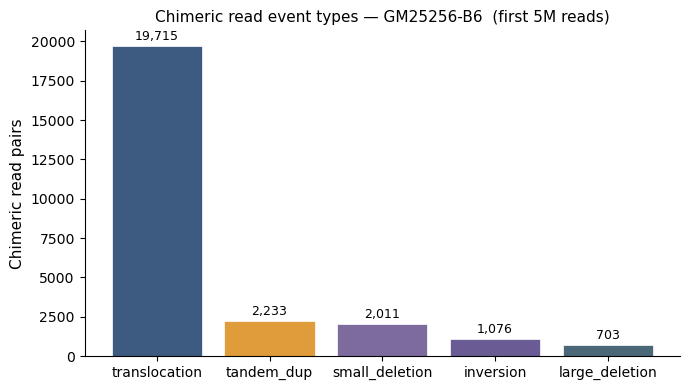

In [172]:
PALETTE = {
    "translocation" : "#3d5a80",
    "inversion"     : "#6b5b95",
    "large_deletion": "#4a6877",
    "small_deletion": "#7d6b9e",
    "tandem_dup"    : "#e09c3b",
}

counts = chimeric_df["event_type"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    counts.index,
    counts.values,
    color=[PALETTE.get(k, "#aaaaaa") for k in counts.index],
    edgecolor="white", linewidth=0.5,
)
for bar, val in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + counts.max() * 0.01,
        f"{val:,}", ha="center", va="bottom", fontsize=9,
    )
ax.set_ylabel("Chimeric read pairs", fontsize=11)
ax.set_title(
    f"Chimeric read event types — GM25256-B6  ({label})",
    fontsize=11,
)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

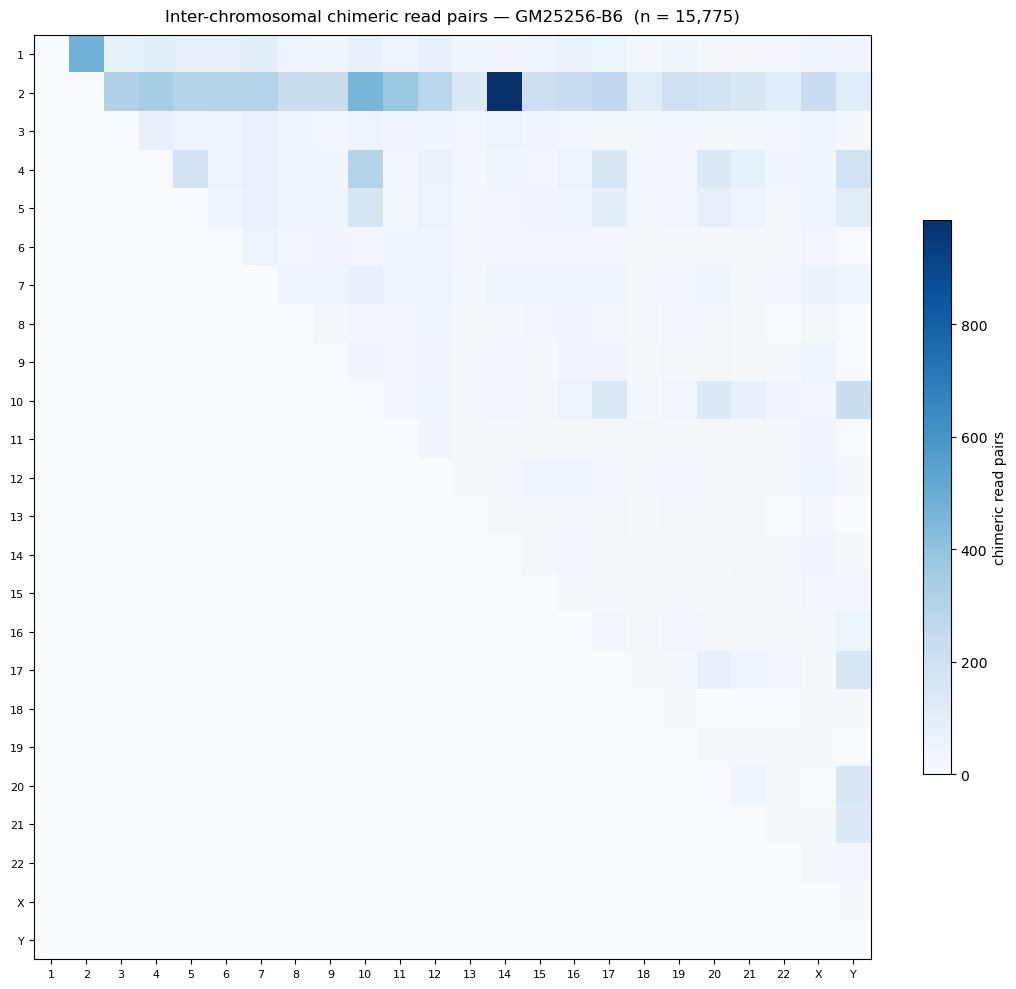

In [173]:
trans = chimeric_df[
    (chimeric_df["event_type"] == "translocation") &
    chimeric_df["chrom1"].isin(CANONICAL) &
    chimeric_df["chrom2"].isin(CANONICAL)
].copy()

# Undirected: always put the lower-index chrom first
ci = {c: i for i, c in enumerate(CANONICAL)}
swap = trans.apply(lambda r: ci[r.chrom1] > ci[r.chrom2], axis=1)
trans.loc[swap, ["chrom1", "chrom2"]] = trans.loc[swap, ["chrom2", "chrom1"]].values

matrix = pd.crosstab(trans["chrom1"], trans["chrom2"]).reindex(
    index=CANONICAL, columns=CANONICAL, fill_value=0
)

fig, ax = plt.subplots(figsize=(11, 10))
im = ax.imshow(matrix.values, cmap="Blues", aspect="auto")
plt.colorbar(im, ax=ax, label="chimeric read pairs", shrink=0.6)

tick_labels = [c.replace("chr", "") for c in CANONICAL]
ax.set_xticks(range(len(CANONICAL)))
ax.set_yticks(range(len(CANONICAL)))
ax.set_xticklabels(tick_labels, fontsize=8)
ax.set_yticklabels(tick_labels, fontsize=8)
ax.set_title(
    f"Inter-chromosomal chimeric read pairs — GM25256-B6  (n = {len(trans):,})",
    fontsize=12, pad=10,
)
plt.tight_layout()
plt.show()

Canonical translocation reads : 15,775
  Fail MAPQ≥30 on either side : 14,574
  Fail flank≥20 bp on either side   : 0
  Have competing full-read aln : 1,768
  Passing unambiguous filter   : 1,179  (7.5%)


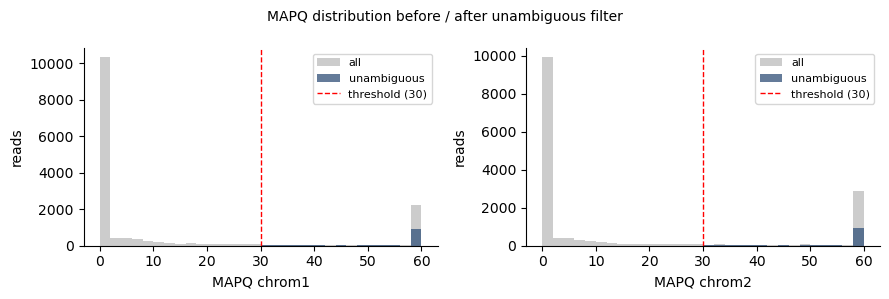

In [174]:

# ── Unambiguous junction filter ────────────────────────────────────────────
# A split read is "unambiguous" when:
#   1. Both alignments map uniquely → MAPQ ≥ MIN_MAPQ on both sides
#   2. Both alignment flanks are long enough to be confidently placed
#      → left flank (portion before junction) ≥ MIN_FLANK bp
#      → right flank (portion after junction) ≥ MIN_FLANK bp
#   3. No competing full-read alignment exists → has_full_aln_alt == False
#      (catches reads that map fully to a repeat / decoy in a single span,
#       suggesting the chimeric signal is an artefact of repetitive sequence)
#
# This removes reads mapping to repeats/alt-contigs with MAPQ=0 on one side
# (which account for ~90% of raw translocation reads).

MIN_MAPQ_UNAMBIG = 30   # both alignments must map with MAPQ ≥ this
MIN_FLANK        = 20   # each alignment portion must span ≥ this many bp

trans_all = chimeric_df[
    (chimeric_df["event_type"] == "translocation") &
    chimeric_df["chrom1"].isin(CANONICAL) &
    chimeric_df["chrom2"].isin(CANONICAL)
].copy()

# Canonical ordering (lower-index chrom = chrom1)
ci = {c: i for i, c in enumerate(CANONICAL)}
swap = trans_all.apply(lambda r: ci[r.chrom1] > ci[r.chrom2], axis=1)
for ca, cb in [("chrom1","chrom2"), ("pos1","pos2"), ("end1","end2"),
               ("strand1","strand2"), ("mapq1","mapq2"),
               ("read_s1","read_s2"), ("read_e1","read_e2")]:
    trans_all.loc[swap, [ca, cb]] = trans_all.loc[swap, [cb, ca]].values

# Per-read junction geometry
trans_all["left_flank"]  = (trans_all[["read_e1","read_e2"]].min(axis=1)
                           - trans_all[["read_s1","read_s2"]].min(axis=1))
trans_all["right_flank"] = (trans_all[["read_e1","read_e2"]].max(axis=1)
                           - trans_all[["read_s1","read_s2"]].max(axis=1))

unambig = (
    (trans_all["mapq1"]            >= MIN_MAPQ_UNAMBIG) &
    (trans_all["mapq2"]            >= MIN_MAPQ_UNAMBIG) &
    (trans_all["left_flank"]       >= MIN_FLANK) &
    (trans_all["right_flank"]      >= MIN_FLANK) &
    (~trans_all["has_full_aln_alt"])
)

print(f"Canonical translocation reads : {len(trans_all):,}")
print(f"  Fail MAPQ≥{MIN_MAPQ_UNAMBIG} on either side : "
      f"{(~((trans_all.mapq1>=MIN_MAPQ_UNAMBIG)&(trans_all.mapq2>=MIN_MAPQ_UNAMBIG))).sum():,}")
print(f"  Fail flank≥{MIN_FLANK} bp on either side   : "
      f"{(~((trans_all.left_flank>=MIN_FLANK)&(trans_all.right_flank>=MIN_FLANK))).sum():,}")
print(f"  Have competing full-read aln : "
      f"{trans_all['has_full_aln_alt'].sum():,}")
print(f"  Passing unambiguous filter   : {unambig.sum():,}  ({100*unambig.mean():.1f}%)")

trans = trans_all[unambig].copy()

# MAPQ distribution before/after
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, col, title in zip(axes, ["mapq1","mapq2"], ["MAPQ chrom1","MAPQ chrom2"]):
    ax.hist(trans_all[col], bins=range(0, 62, 2), color="#aaaaaa", alpha=0.6, label="all")
    ax.hist(trans[col],     bins=range(0, 62, 2), color="#3d5a80", alpha=0.8, label="unambiguous")
    ax.axvline(MIN_MAPQ_UNAMBIG, color="red", ls="--", lw=1, label=f"threshold ({MIN_MAPQ_UNAMBIG})")
    ax.set_xlabel(title); ax.set_ylabel("reads")
    ax.legend(fontsize=8); ax.spines[["top","right"]].set_visible(False)
plt.suptitle("MAPQ distribution before / after unambiguous filter", fontsize=10)
plt.tight_layout()
plt.show()


In [175]:

# ── Cluster unambiguous translocation reads into junctions (10 kb bins) ───
# `trans` = unambiguous reads only (defined in the cell above).
# Bin both breakpoints into 10 kb windows; reads straddling a bin boundary
# may split across two bins (known limitation of floor-division binning).

BIN = 10_000

trans["bin1"] = (trans["end1"] // BIN) * BIN
trans["bin2"] = (trans["pos2"] // BIN) * BIN

junctions = (
    trans
    .groupby(["chrom1", "bin1", "chrom2", "bin2"], sort=False)
    .agg(
        n_reads      = ("read_name", "nunique"),
        bp1_median   = ("end1",  "median"),
        bp1_spread   = ("end1",  lambda x: int(x.max() - x.min())),
        bp2_median   = ("pos2",  "median"),
        bp2_spread   = ("pos2",  lambda x: int(x.max() - x.min())),
        r1_support   = ("read_end", lambda x: (x == "R1").sum()),
        r2_support   = ("read_end", lambda x: (x == "R2").sum()),
        mapq1_median = ("mapq1", "median"),
        mapq2_median = ("mapq2", "median"),
    )
    .reset_index()
    .sort_values("n_reads", ascending=False)
    .reset_index(drop=True)
)

junctions["label"] = (
    junctions["chrom1"].str.replace("chr", "") + ":"
    + junctions["bp1_median"].astype(int).map(lambda x: f"{x:,}")
    + " → "
    + junctions["chrom2"].str.replace("chr", "") + ":"
    + junctions["bp2_median"].astype(int).map(lambda x: f"{x:,}")
)
junctions["tight"] = (junctions["bp1_spread"] <= 200) & (junctions["bp2_spread"] <= 200)

print(f"Unique translocation junctions (unambiguous reads, 10 kb bins): {len(junctions):,}")
print(f"  tight (bp spread ≤ 200 bp on both sides): {junctions['tight'].sum():,}")
print(f"\nTop 25:")
display(
    junctions[["label", "n_reads", "bp1_spread", "bp2_spread",
               "r1_support", "r2_support", "mapq1_median", "mapq2_median", "tight"]]
    .head(25)
    .style.bar(subset=["n_reads"], color="#3d5a80")
)


Unique translocation junctions (unambiguous reads, 10 kb bins): 1,008
  tight (bp spread ≤ 200 bp on both sides): 1,007

Top 25:


,label,n_reads,bp1_spread,bp2_spread,r1_support,r2_support,mapq1_median,mapq2_median,tight
0,"9:91,523,353 → X:108,993,432",4,0,0,4,0,60.000000,60.000000,True
1,"7:128,176,263 → 12:117,826,921",3,0,0,0,3,60.000000,60.000000,True
2,"2:200,701,115 → 13:25,166,819",3,0,0,0,3,60.000000,60.000000,True
3,"5:160,131,326 → X:53,961,261",3,30,30,3,3,57.000000,60.000000,True
4,"13:21,277,684 → 19:53,371,289",3,0,0,0,3,60.000000,60.000000,True
5,"11:28,252,009 → 13:50,756,313",3,0,0,0,3,60.000000,60.000000,True
6,"7:108,100,351 → 11:40,559,613",3,0,0,3,0,60.000000,60.000000,True
7,"5:30,284,041 → 20:50,674,808",3,0,0,3,0,60.000000,44.000000,True
8,"3:93,470,478 → 4:49,710,067",3,10,1049,3,0,60.000000,50.000000,False
9,"12:8,730,087 → 21:24,940,487",3,0,0,0,3,60.000000,60.000000,True


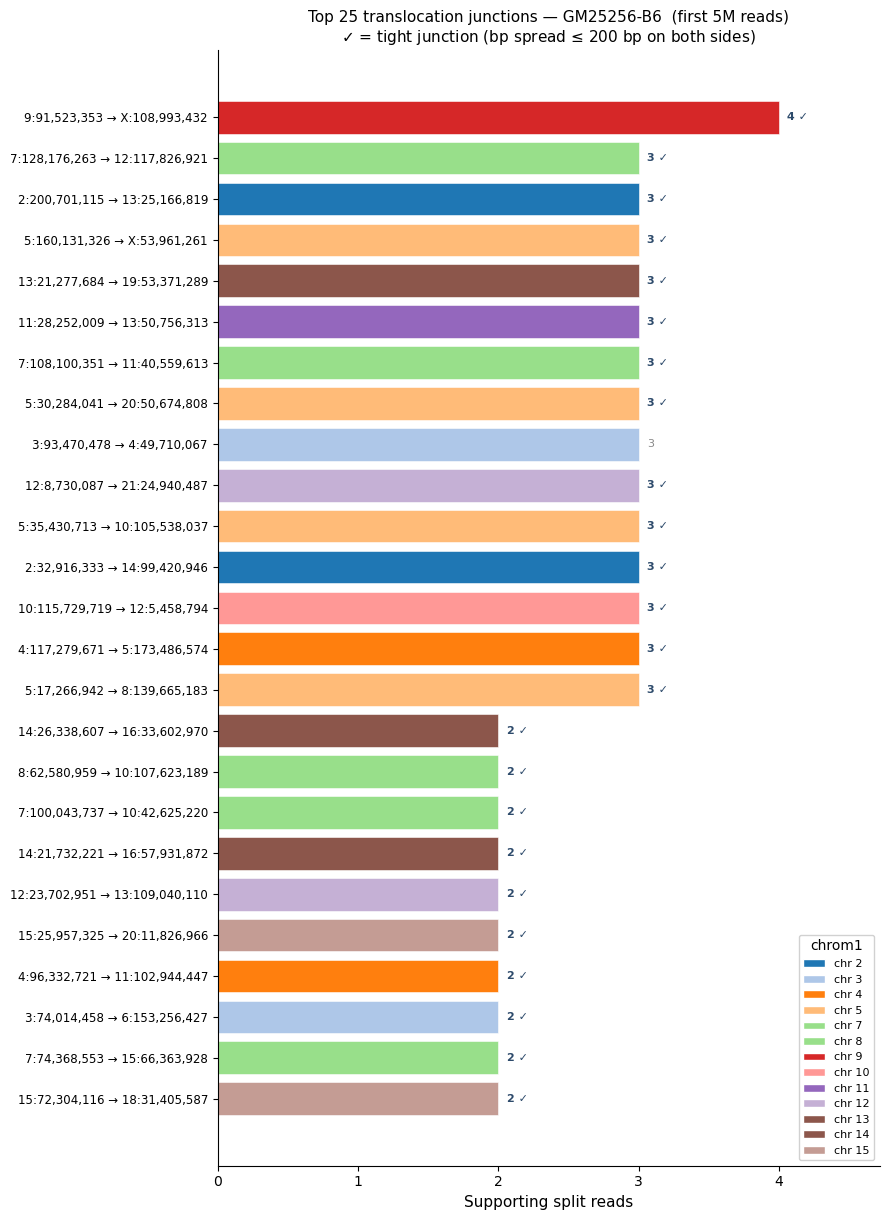

In [176]:
TOP_N = 25
top = junctions.head(TOP_N).iloc[::-1].reset_index(drop=True)  # reversed for barh

# Assign a color per source chromosome
chrom_palette = {}
cmap = plt.cm.tab20
for idx, c in enumerate(CANONICAL):
    chrom_palette[c] = cmap(idx / len(CANONICAL))

bar_colors = [chrom_palette.get(c, "#aaaaaa") for c in top["chrom1"]]

fig, ax = plt.subplots(figsize=(9, TOP_N * 0.42 + 1.8))
y = range(len(top))

bars = ax.barh(list(y), top["n_reads"],
               color=bar_colors, edgecolor="white", linewidth=0.4)

# Annotate: count + tight marker
for yi, (_, row) in enumerate(top.iterrows()):
    tight_mark = " ✓" if row["tight"] else ""
    ax.text(
        row["n_reads"] + top["n_reads"].max() * 0.015, yi,
        f'{int(row["n_reads"])}{tight_mark}',
        va="center", fontsize=8,
        color="#2d4a6b" if row["tight"] else "#888888",
        fontweight="bold" if row["tight"] else "normal",
    )

ax.set_yticks(list(y))
ax.set_yticklabels(top["label"], fontsize=8.5)
ax.set_xlabel("Supporting split reads", fontsize=11)
ax.set_title(
    f"Top {TOP_N} translocation junctions — GM25256-B6  ({label})\n"
    r"$\checkmark$ = tight junction (bp spread ≤ 200 bp on both sides)",
    fontsize=11,
)
ax.set_xlim(0, top["n_reads"].max() * 1.18)
ax.spines[["top", "right"]].set_visible(False)

# Chromosome legend (only chroms that appear in top N)
seen_chroms = top["chrom1"].unique()
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, fc=chrom_palette[c], ec="white", label=c.replace("chr", "chr "))
    for c in CANONICAL if c in seen_chroms
]
ax.legend(handles=legend_handles, title="chrom1", fontsize=8,
          loc="lower right", framealpha=0.9)

plt.tight_layout()
plt.show()

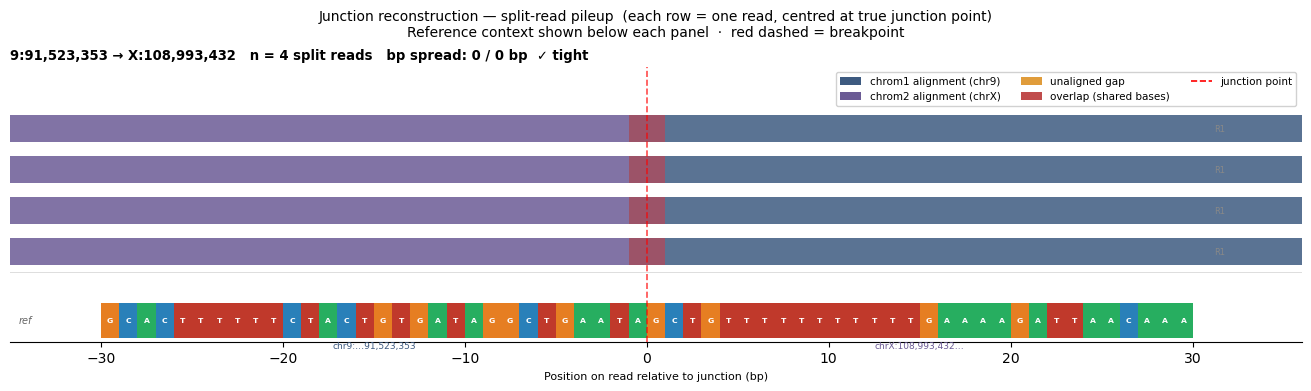

In [177]:
# ── Junction reconstruction ────────────────────────────────────────────────
# For each top junction, we re-centre every supporting read at its true
# split point: the midpoint between the end of the left alignment and the
# start of the right alignment on the read (in forward-read coordinates).
#
# Why not use read_e1?  After the canonical-chrom swap, read_e1 may become
# the END of the RIGHT alignment — far from the actual junction. The correct
# split point is always:
#
#   split = ( min(read_e1, read_e2)   ← end of whichever alignment is left
#           + max(read_s1, read_s2) ) / 2   ← start of whichever is right
#
# Positive gap  (right_start > left_end) → unaligned bases between alns
# Negative gap  (right_start < left_end) → the two alns overlap on the read

import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

CONTEXT_BP     = 30    # reference bases to show on each side of the breakpoint
TOP_VIZ        = 6     # top junctions to visualise
MAX_READS_SHOW = 30    # cap reads per panel (display only)

CLR_CHR1 = "#3d5a80"   # dark steel blue — chrom1 alignment
CLR_CHR2 = "#6b5b95"   # muted purple    — chrom2 alignment
CLR_GAP  = "#e09c3b"   # amber           — unaligned gap between alignments
CLR_OVL  = "#c04c4c"   # muted red       — overlap region (both alns claim it)
BASE_CLR = {"A": "#27ae60", "T": "#c0392b", "C": "#2980b9",
            "G": "#e67e22", "N": "#bdc3c7"}

fasta = pysam.FastaFile(REFERENCE)

junctions_viz = junctions[junctions["n_reads"] >= MIN_JUNCTION_READS]
n_panels = min(TOP_VIZ, len(junctions_viz))
fig, axes = plt.subplots(n_panels, 1, figsize=(13, n_panels * 3.8),
                         constrained_layout=True)
if n_panels == 1:
    axes = [axes]

for jidx, (_, jrow) in enumerate(junctions_viz.head(n_panels).iterrows()):
    ax = axes[jidx]

    # ── Reads supporting this junction ────────────────────────────────
    mask = (
        (trans["chrom1"] == jrow.chrom1) & (trans["bin1"] == jrow.bin1) &
        (trans["chrom2"] == jrow.chrom2) & (trans["bin2"] == jrow.bin2)
    )
    reads = trans[mask].sort_values("end1").head(MAX_READS_SHOW)

    ax.set_xlim(-CONTEXT_BP - 5, CONTEXT_BP + 6)
    ax.set_ylim(-2.2, len(reads) + 0.5)

    # ── Reference context strip ────────────────────────────────────────
    bp1 = int(jrow.bp1_median)
    bp2 = int(jrow.bp2_median)
    try:
        seq1 = fasta.fetch(jrow.chrom1, max(0, bp1 - CONTEXT_BP), bp1).upper()
        seq2 = fasta.fetch(jrow.chrom2, bp2, bp2 + CONTEXT_BP).upper()
    except Exception:
        seq1 = "N" * CONTEXT_BP
        seq2 = "N" * CONTEXT_BP

    for xi, base in enumerate(seq1):
        x = xi - CONTEXT_BP
        ax.add_patch(FancyBboxPatch((x, -2.1), 1, 0.85, boxstyle="square,pad=0",
                     fc=BASE_CLR.get(base, "#bdc3c7"), ec="none", zorder=2))
        ax.text(x + 0.5, -1.67, base, ha="center", va="center",
                fontsize=5.5, color="white", fontweight="bold", zorder=3)
    for xi, base in enumerate(seq2):
        x = xi
        ax.add_patch(FancyBboxPatch((x, -2.1), 1, 0.85, boxstyle="square,pad=0",
                     fc=BASE_CLR.get(base, "#bdc3c7"), ec="none", zorder=2))
        ax.text(x + 0.5, -1.67, base, ha="center", va="center",
                fontsize=5.5, color="white", fontweight="bold", zorder=3)

    ax.text(-CONTEXT_BP - 4.5, -1.67, "ref", ha="left", va="center",
            fontsize=7, color="#666", style="italic")
    ax.text(-CONTEXT_BP / 2, -2.18, f"{jrow.chrom1}:…{bp1:,}",
            ha="center", va="top", fontsize=6.5, color=CLR_CHR1)
    ax.text(CONTEXT_BP / 2, -2.18, f"{jrow.chrom2}:{bp2:,}…",
            ha="center", va="top", fontsize=6.5, color=CLR_CHR2)

    # ── Per-read pileup ────────────────────────────────────────────────
    for ridx, (_, rrow) in enumerate(reads.iterrows()):
        rs1, re1 = rrow.read_s1, rrow.read_e1
        rs2, re2 = rrow.read_s2, rrow.read_e2

        # True junction: midpoint between the end of the left aln
        # and the start of the right aln on the read
        left_end    = min(re1, re2)
        right_start = max(rs1, rs2)
        split = (left_end + right_start) / 2

        # Relative positions centred on the junction
        s1r, e1r = rs1 - split, re1 - split
        s2r, e2r = rs2 - split, re2 - split
        y, h = ridx, 0.65

        ax.barh(y, e1r - s1r, left=s1r, height=h,
                color=CLR_CHR1, alpha=0.85, linewidth=0, zorder=3)
        ax.barh(y, e2r - s2r, left=s2r, height=h,
                color=CLR_CHR2, alpha=0.85, linewidth=0, zorder=3)

        gap = right_start - left_end   # positive = gap, negative = overlap
        if gap > 0:
            ax.barh(y, gap, left=left_end - split, height=h,
                    color=CLR_GAP, alpha=0.75, linewidth=0, zorder=4)
        elif gap < 0:
            ax.barh(y, -gap, left=right_start - split, height=h,
                    color=CLR_OVL, alpha=0.6, linewidth=0, zorder=4)

        ax.text(CONTEXT_BP + 1.2, y, rrow.read_end,
                ha="left", va="center", fontsize=6, color="#888")

    # ── Decoration ────────────────────────────────────────────────────
    ax.axvline(0, color="red", lw=1.2, ls="--", alpha=0.7, zorder=5)
    ax.axhline(-0.5, color="#dddddd", lw=0.7)

    tight_str = "  ✓ tight" if jrow.tight else ""
    ax.set_title(
        f"{jrow.label}   n = {int(jrow.n_reads)} split reads   "
        f"bp spread: {jrow.bp1_spread} / {jrow.bp2_spread} bp{tight_str}",
        fontsize=9.5, fontweight="bold", loc="left",
    )
    ax.set_xlabel("Position on read relative to junction (bp)", fontsize=8)
    ax.set_yticks([])
    ax.spines[["top", "right", "left"]].set_visible(False)

    if jidx == 0:
        handles = [
            mpatches.Patch(fc=CLR_CHR1, label=f"chrom1 alignment ({jrow.chrom1})"),
            mpatches.Patch(fc=CLR_CHR2, label=f"chrom2 alignment ({jrow.chrom2})"),
            mpatches.Patch(fc=CLR_GAP,  label="unaligned gap"),
            mpatches.Patch(fc=CLR_OVL,  label="overlap (shared bases)"),
            plt.Line2D([0], [0], color="red", ls="--", lw=1.2, label="junction point"),
        ]
        ax.legend(handles=handles, loc="upper right", fontsize=7.5,
                  framealpha=0.9, ncol=3)

fasta.close()

plt.suptitle(
    "Junction reconstruction — split-read pileup  "
    "(each row = one read, centred at true junction point)\n"
    "Reference context shown below each panel  ·  red dashed = breakpoint",
    fontsize=10,
)
plt.show()

In [ ]:

# ── Save reconstructed junction sequences ─────────────────────────────────
# For every junction in `junctions`, fetch CONTEXT_BP bp of reference on
# each side of the median breakpoint and upload two files to S3:
#
#   junction_sequences.fa   — FASTA, one entry per junction
#   junction_sequences.csv  — CSV with per-junction context columns

import os
import subprocess
import tempfile

fasta = pysam.FastaFile(REFERENCE)

rows = []
fasta_lines = []

for _, jrow in junctions.iterrows():
    bp1 = int(jrow.bp1_median)
    bp2 = int(jrow.bp2_median)
    try:
        seq1 = fasta.fetch(jrow.chrom1, max(0, bp1 - CONTEXT_BP), bp1).upper()
        seq2 = fasta.fetch(jrow.chrom2, bp2, bp2 + CONTEXT_BP).upper()
    except Exception:
        seq1 = "N" * CONTEXT_BP
        seq2 = "N" * CONTEXT_BP

    junction_seq = seq1 + seq2

    header = (
        f">{jrow.label.replace(' ', '_')}  "
        f"n_reads={int(jrow.n_reads)}  "
        f"bp1_spread={jrow.bp1_spread}  bp2_spread={jrow.bp2_spread}  "
        f"tight={'Y' if jrow.tight else 'N'}"
    )
    fasta_lines.append(header)
    fasta_lines.append(junction_seq)

    rows.append({
        "label"        : jrow.label,
        "chrom1"       : jrow.chrom1,
        "bp1"          : bp1,
        "seq_chrom1"   : seq1,
        "chrom2"       : jrow.chrom2,
        "bp2"          : bp2,
        "seq_chrom2"   : seq2,
        "junction_seq" : junction_seq,
        "n_reads"      : int(jrow.n_reads),
        "bp1_spread"   : jrow.bp1_spread,
        "bp2_spread"   : jrow.bp2_spread,
        "tight"        : jrow.tight,
        "r1_support"   : int(jrow.r1_support),
        "r2_support"   : int(jrow.r2_support),
        "mapq1_median" : jrow.mapq1_median,
        "mapq2_median" : jrow.mapq2_median,
    })

fasta.close()

seq_df = pd.DataFrame(rows)

# Write to temp files, upload to S3, delete
uploads = {}
with tempfile.NamedTemporaryFile(mode="w", suffix=".fa",  delete=False) as fh:
    fh.write("\n".join(fasta_lines) + "\n")
    uploads[fh.name] = S3_BASE + "junction_sequences.fa"

with tempfile.NamedTemporaryFile(mode="w", suffix=".csv", delete=False) as fh:
    seq_df.to_csv(fh, index=False)
    uploads[fh.name] = S3_BASE + "junction_sequences.csv"

for local, remote in uploads.items():
    result = subprocess.run(["aws", "s3", "cp", local, remote, "--quiet"],
                            capture_output=True, text=True)
    if result.returncode == 0:
        print(f"Uploaded {len(seq_df):,} junctions → {remote}")
    else:
        print(f"Upload error ({remote}):", result.stderr)
    os.unlink(local)

print(f"\nFirst 5 entries:")
display(seq_df[["label", "seq_chrom1", "seq_chrom2", "n_reads", "tight"]].head())


In [ ]:

# ── Per-junction read FASTA files ─────────────────────────────────────────
import re
import subprocess
import tempfile
import shutil
from pathlib import Path

S3_DEST = S3_BASE + "junction_reads/"

def _rc(seq):
    comp = str.maketrans("ACGTNacgtn", "TGCANtgcan")
    return seq.translate(comp)[::-1]

def _safe_fname(label):
    return re.sub(r"[^A-Za-z0-9_\-]", "_",
                  label.replace(" → ", "_to_").replace(",", ""))

# ── 1. Filter junctions and find which trans rows belong to them ───────────
junctions_filtered = junctions[junctions["n_reads"] >= MIN_JUNCTION_READS].copy()
print(f"Junctions with ≥{MIN_JUNCTION_READS} reads: "
      f"{len(junctions_filtered):,} / {len(junctions):,}")

join_cols = ["chrom1", "bin1", "chrom2", "bin2"]
trans_filt = trans.merge(junctions_filtered[join_cols], on=join_cols, how="inner")
target_keys = set(zip(trans_filt["read_name"], trans_filt["read_end"] == "R1"))
print(f"Reads to fetch: {len(target_keys):,}  (trans rows matched: {len(trans_filt):,})")

# ── 2. Scan CRAM ───────────────────────────────────────────────────────────
print("Scanning CRAM for primary sequences…")
t0 = time.time()
sequences = {}

cram = pysam.AlignmentFile(CRAM_FILE, "rc", reference_filename=REFERENCE, threads=4)
for aln in cram:
    if aln.is_secondary or aln.is_supplementary or aln.is_unmapped:
        continue
    key = (aln.query_name, aln.is_read1)
    if key not in target_keys or key in sequences:
        continue
    raw = aln.query_sequence or ""
    sequences[key] = _rc(raw) if aln.is_reverse else raw
    if len(sequences) == len(target_keys):
        break
cram.close()

n_found = len(sequences)
print(f"Fetched {n_found:,} / {len(target_keys):,} sequences  ({time.time()-t0:.0f}s)")
if n_found < len(target_keys):
    print(f"  Warning: {len(target_keys) - n_found} reads not found in CRAM")

# ── 3. Write to temp dir, sync to S3, delete ──────────────────────────────
n_written = 0
n_empty   = 0

tmp_dir = Path(tempfile.mkdtemp(prefix="junc_reads_"))
print(f"Writing to temp dir: {tmp_dir}")
try:
    for _, jrow in junctions_filtered.iterrows():
        mask = (
            (trans_filt["chrom1"] == jrow.chrom1) & (trans_filt["bin1"] == jrow.bin1) &
            (trans_filt["chrom2"] == jrow.chrom2) & (trans_filt["bin2"] == jrow.bin2)
        )
        junc_reads = trans_filt[mask]

        lines = []
        for _, rrow in junc_reads.iterrows():
            key = (rrow.read_name, rrow.read_end == "R1")
            seq = sequences.get(key)
            if not seq:
                continue

            rs1, re1 = int(rrow.read_s1), int(rrow.read_e1)
            rs2, re2 = int(rrow.read_s2), int(rrow.read_e2)
            N = len(seq)

            if rs1 > rs2:
                seq = _rc(seq)
                rs1, re1 = N - re1, N - rs1
                rs2, re2 = N - re2, N - rs2

            split = (min(re1, re2) + max(rs1, rs2)) // 2
            header = (
                f">{rrow.read_name}_{rrow.read_end}"
                f"  junc={split}"
                f"  {rrow.chrom1}:{rs1}-{re1}"
                f"  {rrow.chrom2}:{rs2}-{re2}"
                f"  mapq={int(rrow.mapq1)}/{int(rrow.mapq2)}"
            )
            lines.append(header)
            lines.append(seq)

        if not lines:
            n_empty += 1
            continue

        fname = tmp_dir / f"{_safe_fname(jrow.label)}.fa"
        with open(fname, "w") as fh:
            fh.write("\n".join(lines) + "\n")
        n_written += 1

    print(f"Wrote {n_written:,} FASTA files")
    if n_empty:
        print(f"  ({n_empty} junctions skipped — no sequences retrieved)")

    print(f"Syncing to {S3_DEST} …")
    result = subprocess.run(
        ["aws", "s3", "sync", str(tmp_dir), S3_DEST, "--quiet"],
        capture_output=True, text=True,
    )
    if result.returncode == 0:
        print("Sync complete.")
    else:
        print("S3 sync error:", result.stderr)

finally:
    shutil.rmtree(tmp_dir)
    print(f"Temp dir deleted.")


In [ ]:
import os, subprocess, tempfile

with tempfile.NamedTemporaryFile(mode="w", suffix=".csv", delete=False) as fh:
    chimeric_df.to_csv(fh, index=False)
    tmp = fh.name

s3_path = S3_BASE + "chimeric_reads_B6.csv"
result = subprocess.run(["aws", "s3", "cp", tmp, s3_path, "--quiet"],
                        capture_output=True, text=True)
os.unlink(tmp)

if result.returncode == 0:
    print(f"Saved {len(chimeric_df):,} events → {s3_path}")
else:
    print("Upload error:", result.stderr)

In [181]:
chimeric_df

,read_name,read_end,chrom1,pos1,end1,strand1,mapq1,read_s1,read_e1,chrom2,pos2,end2,strand2,mapq2,read_s2,read_e2,overlap_bp,event_type,has_full_aln_alt
0,HMJG5DSX2211027:2:1101:1108:14904,R1,chr2,125532559,125532669,+,60,0,110,chr22,34601417,34601478,+,45,90,151,20,translocation,False
1,HMJG5DSX2211027:2:1101:1108:19257,R1,chrY,10750787,10750849,-,0,89,151,chr22_KI270736v1_random,155824,155859,+,0,2,37,-52,translocation,False
2,HMJG5DSX2211027:2:1101:1108:19257,R2,chr17_KI270730v1_random,91699,91746,-,0,84,131,chrUn_KI270442v1,67734,67797,-,0,0,63,-21,translocation,False
3,HMJG5DSX2211027:2:1101:1127:32346,R1,chr12,101920384,101920474,+,60,61,151,chr12,101920221,101920302,+,60,0,81,20,small_deletion,False
4,HMJG5DSX2211027:2:1101:1145:3035,R2,chrY,11747663,11747753,+,23,0,90,chr17,21920684,21920724,+,17,105,145,-15,translocation,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25733,HMJG5DSX2211027:2:1121:20229:34585,R1,chr3,196164745,196164802,+,60,0,57,chr3,196165516,196165616,+,44,51,151,6,small_deletion,False
25734,HMJG5DSX2211027:2:1121:20229:34585,R2,chr3,196165516,196165623,-,60,0,107,chr3,196164752,196164802,-,5,101,151,6,small_deletion,False
25735,HMJG5DSX2211027:2:1121:20238:15843,R1,chr2,52772578,52772688,+,60,41,151,chr5,93544835,93544896,+,45,0,61,20,translocation,False
25736,HMJG5DSX2211027:2:1121:20247:15671,R2,chr17,23714686,23714815,+,0,22,151,chr17,25470633,25470675,+,0,0,42,20,tandem_dup,False
